# setup de caminhos e conexão

In [33]:
import sqlite3
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# caminhos
pasta_scripts = '../scripts'
banco_dados = '../marvel.db'

def conectar():
    return sqlite3.connect(banco_dados)

# célula de sincronização

In [34]:
conn = conectar()
cursor = conn.cursor()

print(f"sincronizando arquivos sql da pasta: {pasta_scripts}")

arquivos_processados = 0
for arquivo in os.listdir(pasta_scripts):
    if arquivo.endswith('.sql'):
        caminho_completo = os.path.join(pasta_scripts, arquivo)
        
        with open(caminho_completo, 'r', encoding='utf-8') as f:
            scripts = f.read()
            try:
                cursor.executescript(scripts)
                conn.commit()
                arquivos_processados += 1
                print(f"{arquivo} carregado.")
            except Exception as e:
                print(f"erro no arquivo {arquivo}: {e}")
print(f"\n sincronização finalizada. {arquivos_processados} arquivos processados.")
conn.close()

sincronizando arquivos sql da pasta: ../scripts
fab_vingadores_01.sql carregado.

 sincronização finalizada. 1 arquivos processados.


# visão geral do acervo

In [35]:
conn = sqlite3.connect('../marvel.db')

total_hqs = pd.read_sql("select count(*) from edicoes_marvel", conn).iloc[0,0]
total_personagens = pd.read_sql("select count(*) from personagens_marvel", conn).iloc[0,0]
total_paineis = pd.read_sql("select count(*) from paineis_marvel", conn).iloc[0,0]

print("-" * 30)
print(f"panorama geral do acervo:")
print("-" * 30)
print(f"edições catalogadas: {total_hqs}")
print(f"elenco cadastrado: {total_personagens} personagens")
print(f"total de painéis: {total_paineis} quadros minerados")

print("\n edições presentes no banco:")
df_lista = pd.read_sql("select serie, edicao, escritor from edicoes_marvel", conn)
print(df_lista.to_string(index=False))

conn.close()

------------------------------
panorama geral do acervo:
------------------------------
edições catalogadas: 1
elenco cadastrado: 1 personagens
total de painéis: 3 quadros minerados

 edições presentes no banco:
                  serie edicao      escritor
os fabulosos vingadores     01 rick remender


# visualizações

## participação por edição (volume de dados)

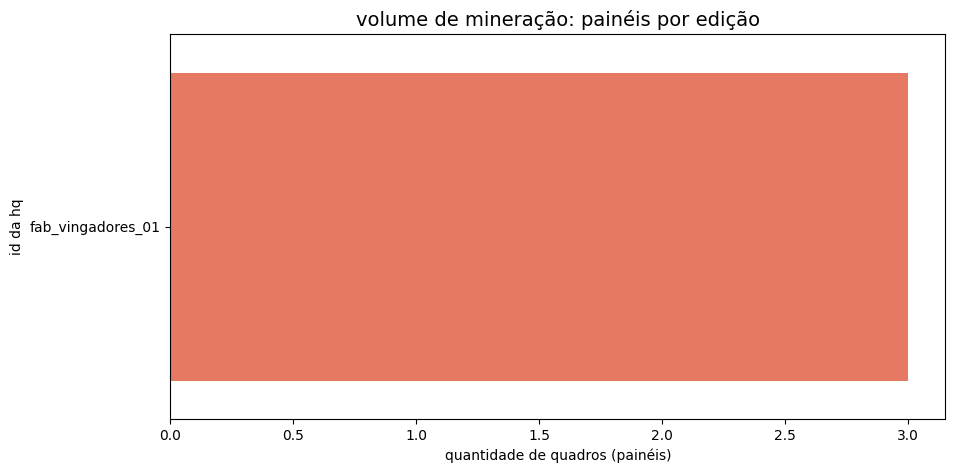

In [36]:
conn = sqlite3.connect('../marvel.db')

# query: conta painéis por edição
query1 = "select id_edicao, count(*) as total_paineis from paineis_marvel group by id_edicao order by total_paineis desc"
df_volume = pd.read_sql(query1, conn)

plt.figure(figsize=(10, 5))
sns.barplot(data=df_volume, x='total_paineis', y='id_edicao', hue='id_edicao', palette='Reds_r', legend=False)
plt.title('volume de mineração: painéis por edição', fontsize=14)
plt.xlabel('quantidade de quadros (painéis)')
plt.ylabel('id da hq')
plt.show()

## elenco recorrente (top personagens)

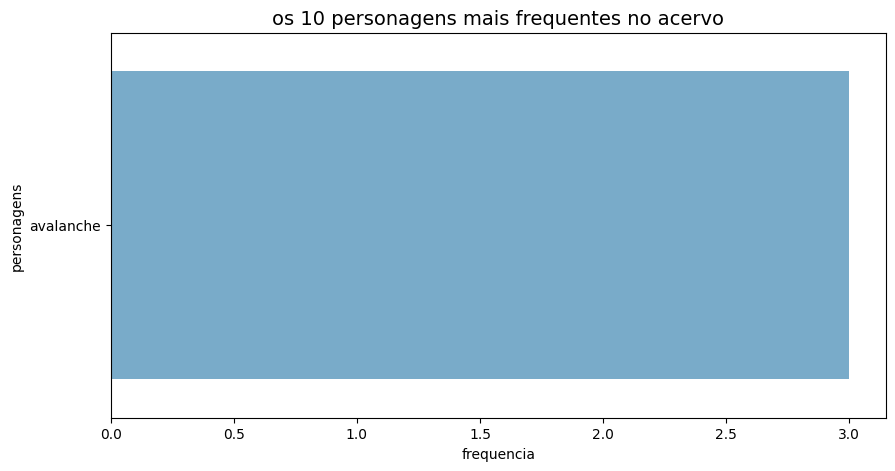

In [37]:
# query: top 10 personagens com mais aparições no acervo total
query2 = "select personagens, count(*) as frequencia from paineis_marvel group by personagens order by frequencia desc limit 10"
df_top_perso = pd.read_sql(query2, conn)

plt.figure(figsize=(10, 5))
sns.barplot(data=df_top_perso, x='frequencia', y='personagens', hue='personagens', palette='Blues_r', legend=False)
plt.title('os 10 personagens mais frequentes no acervo', fontsize=14)
plt.show()

## anatomia da narrativa (enquadramentos globais)

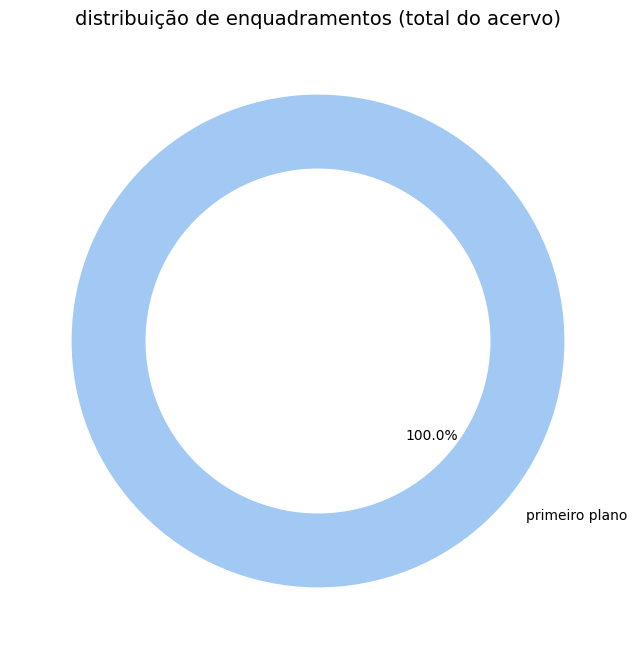

In [38]:
# query: distribuição de enquadramentos no acervo todo
query3 = "select enquadramento, count(*) as qtd from paineis_marvel group by enquadramento"
df_frames = pd.read_sql(query3, conn)

# gráfico de rosca (donut chart)
plt.figure(figsize=(8, 8))
plt.pie(df_frames['qtd'], labels=df_frames['enquadramento'], autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('distribuição de enquadramentos (total do acervo)', fontsize=14)
plt.show()

conn.close()

## ranking de produtividade (escritores, desenhistas, arte-finalistas, coloristas, letristas e editores)

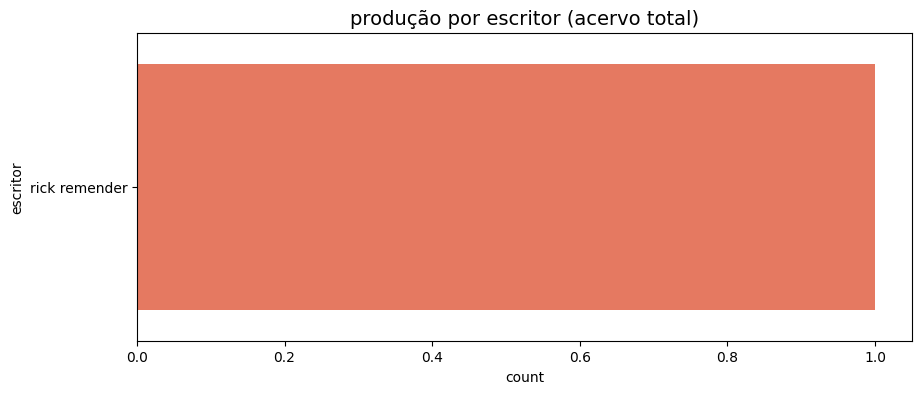

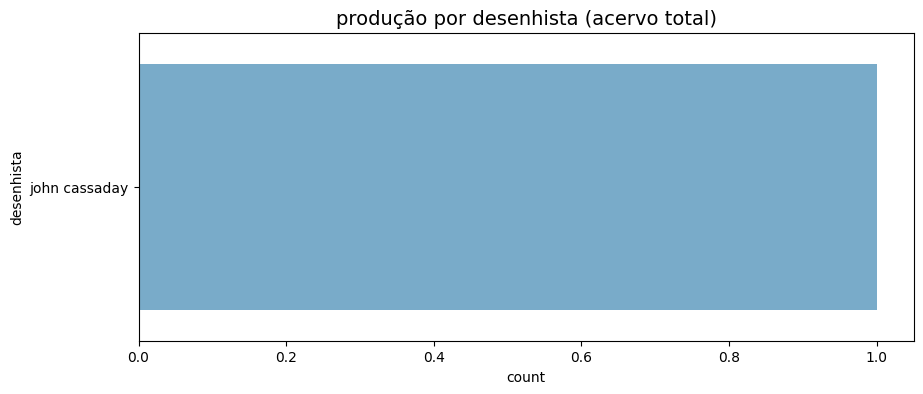

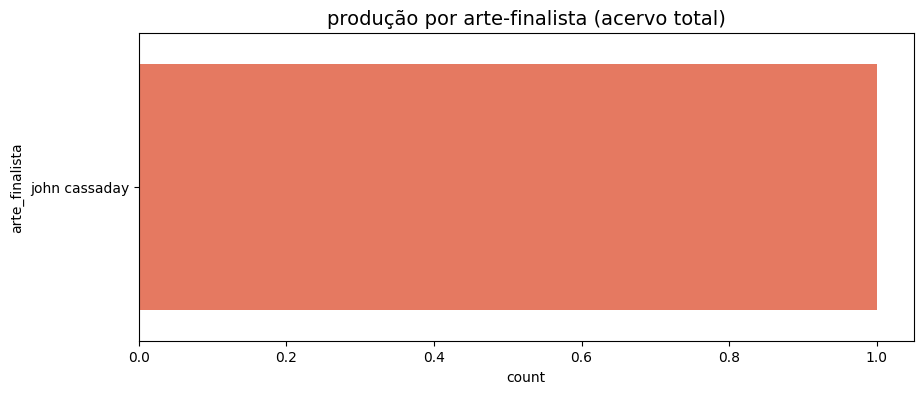

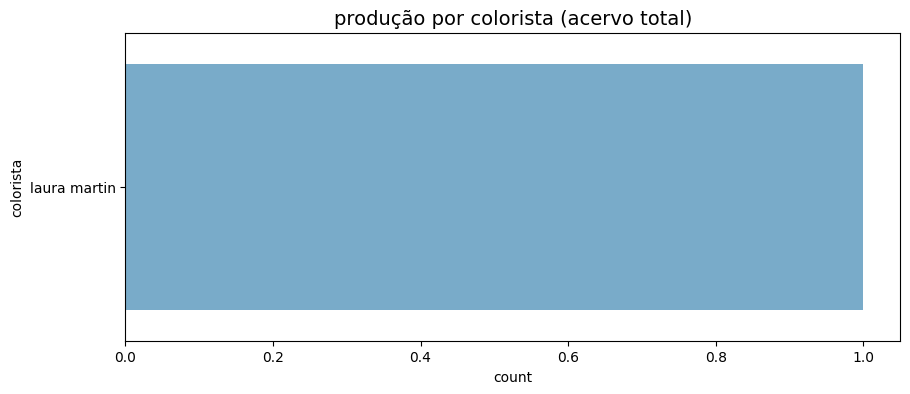

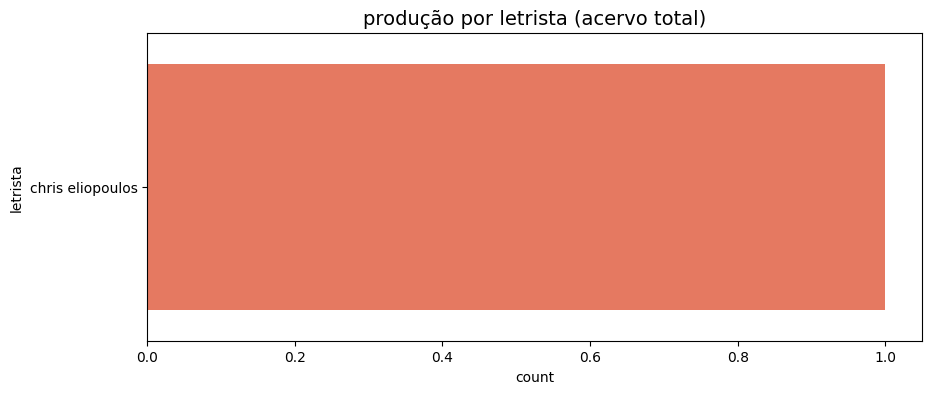

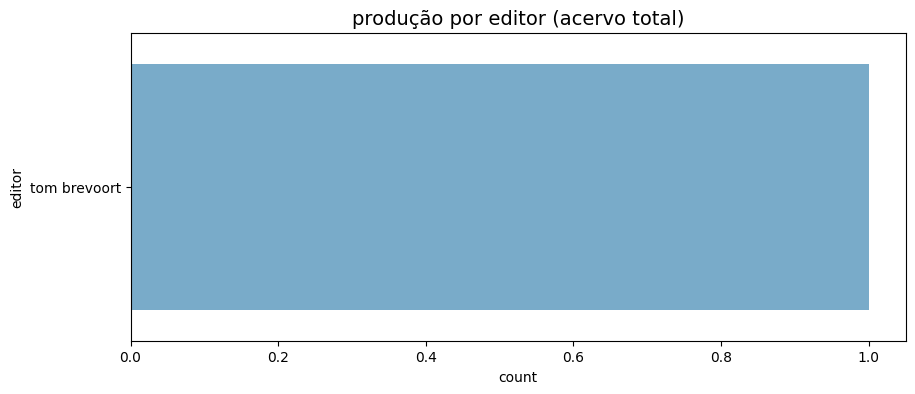

In [39]:
conn = sqlite3.connect('../marvel.db')

# busca os dados de autores
df_autores = pd.read_sql("select escritor, desenhista, arte_finalista, colorista, letrista, editor from edicoes_marvel", conn)

# gráfico de escritores
plt.figure(figsize=(10, 4))
sns.countplot(data=df_autores, y='escritor', hue='escritor', palette='Reds_r', legend=False)
plt.title('produção por escritor (acervo total)', fontsize=14)
plt.show()

# gráfico de desenhistas
plt.figure(figsize=(10, 4))
sns.countplot(data=df_autores, y='desenhista', hue='desenhista', palette='Blues_r', legend=False)
plt.title('produção por desenhista (acervo total)', fontsize=14)
plt.show()

# gráfico de arte-finalistas
plt.figure(figsize=(10, 4))
sns.countplot(data=df_autores, y='arte_finalista', hue='arte_finalista', palette='Reds_r', legend=False)
plt.title('produção por arte-finalista (acervo total)', fontsize=14)
plt.show()

# gráfico de coloristas
plt.figure(figsize=(10, 4))
sns.countplot(data=df_autores, y='colorista', hue='colorista', palette='Blues_r', legend=False)
plt.title('produção por colorista (acervo total)', fontsize=14)
plt.show()

# gráfico de letristas
plt.figure(figsize=(10, 4))
sns.countplot(data=df_autores, y='letrista', hue='letrista', palette='Reds_r', legend=False)
plt.title('produção por letrista (acervo total)', fontsize=14)
plt.show()

# gráfico de editores
plt.figure(figsize=(10, 4))
sns.countplot(data=df_autores, y='editor', hue='editor', palette='Blues_r', legend=False)
plt.title('produção por editor (acervo total)', fontsize=14)
plt.show()

## distribuição de alinhamento (heróis vs. vilões)

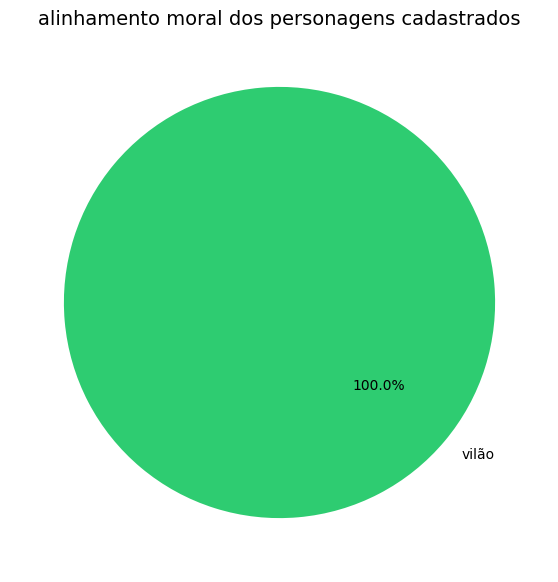

In [40]:
# query para contar o alinhamento
query_alinhamento = "select alinhamento, count(*) as total from personagens_marvel group by alinhamento"
df_moral = pd.read_sql(query_alinhamento, conn)

plt.figure(figsize=(7, 7))
colors = ['#2ecc71', '#e74c3c', '#95a5a6'] # verde (herói), vermelho (vilão), cinza (anti-herói)
plt.pie(df_moral['total'], labels=df_moral['alinhamento'], autopct='%1.1f%%', colors=colors, startangle=140)
plt.title('alinhamento moral dos personagens cadastrados', fontsize=14)
plt.show()

## diversidade de espécies e gênero

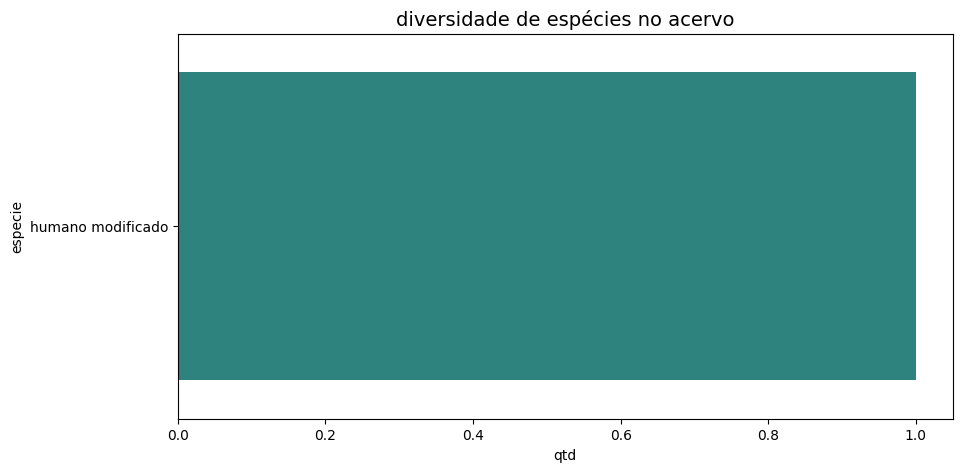

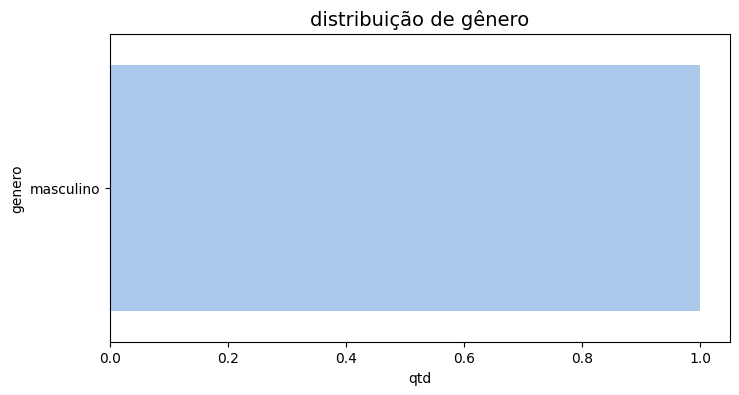

In [41]:
# dados de espécie
df_especie = pd.read_sql("select especie, count(*) as qtd from personagens_marvel group by especie order by qtd desc", conn)

plt.figure(figsize=(10, 5))
sns.barplot(data=df_especie, x='qtd', y='especie', hue='especie', palette='viridis', legend=False)
plt.title('diversidade de espécies no acervo', fontsize=14)
plt.show()

# dados de gênero
df_genero = pd.read_sql("select genero, count(*) as qtd from personagens_marvel group by genero", conn)

plt.figure(figsize=(8, 4))
sns.barplot(data=df_genero, x='qtd', y='genero', hue='genero', palette='pastel', legend=False)
plt.title('distribuição de gênero', fontsize=14)
plt.show()

## timeline de lançamentos (volume por período)

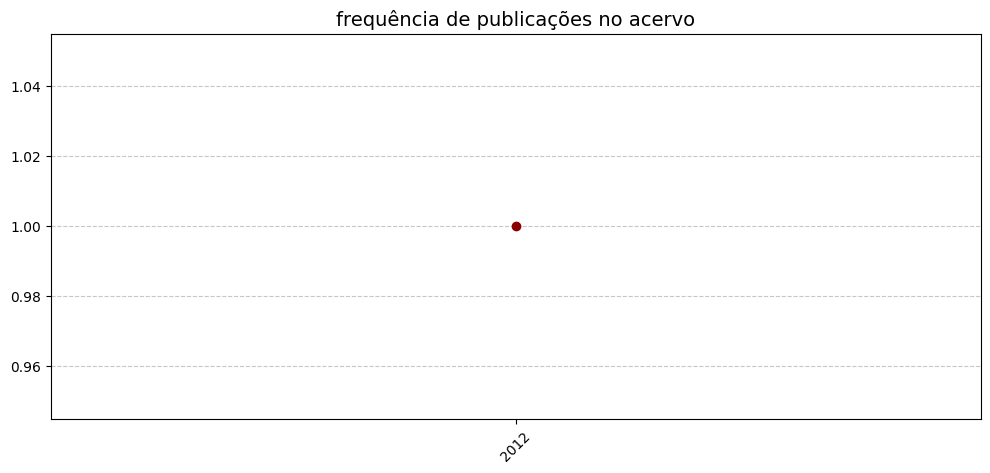

In [42]:
# query para pegar a data de lançamento
df_datas = pd.read_sql("select lancamento, count(*) as total from edicoes_marvel group by lancamento", conn)

plt.figure(figsize=(12, 5))
plt.plot(df_datas['lancamento'], df_datas['total'], marker='o', linestyle='-', color='darkred')
plt.title('frequência de publicações no acervo', fontsize=14)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

conn.close()